# The Mainstreaming of Capitalism: Measuring the Effect of the Russian Revolution on Capitalism's Influence

**Abstract**

Karl Marx's low academic stature *within economics* diverges sharply from his high stature *outside* it — a puzzle Magness & Makovi (2023) resolve by crediting the 1917 Russian Revolution. We replicate their exercise with a minor substitution: the treated unit is now "capitalism" rather than "Karl Marx." Using the identical synthetic control method, the identical treatment year, and the identical data source, we find that capitalism's academic prominence also surged dramatically following the Russian Revolution. We conclude that the Russian Revolution was equally responsible for mainstreaming capitalism, suggesting either (a) that Lenin was history's most effective free-market evangelist, or (b) that the method proves whatever you point it at. We do not adjudicate between these hypotheses. We find a significant treatment effect.

> *This paper is a non-strict methodological replication of Magness & Makovi (2023),* Journal of Political Economy*, vol. 131, no. 6. All design choices — treatment year, data source, estimation method, and the decision to stop the analysis window before an inconvenient confounder — are inherited directly from that paper. Complaints about the methodology should be addressed to the editors of the* Journal of Political Economy.

---
## 0. Setup

In [129]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy.optimize import minimize

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

---
## I. Data

Our outcome variable is Google Ngram frequency in the English 2019 corpus — the same measure used by Magness & Makovi (2023), who describe it as a proxy for "academic influence." We accept this characterisation without question, as questioning it would also invalidate our replication, which would be inconvenient.

**Treated unit**: `capitalism` — a word whose frequency in printed books Magness & Makovi (2023) implicitly treat as equivalent to intellectual merit, a methodological assumption we adopt with equal confidence.

**Donor pool**: A curated selection of political-economic -isms whose Ngram trajectories were *in principle* unaffected by the Russian Revolution, modulo the minor detail that a global communist revolution probably increased discourse about every political ideology simultaneously. We note that Magness & Makovi face the identical problem with their donor pool of socialist thinkers and resolve it by not mentioning it.

**Treatment year**: 1917. Identical to Magness & Makovi (2023). The choice of treatment date does not affect our conclusions, which were settled before we ran the regression.

In [ ]:
TREATMENT_WORD = "capitalism"
TREATMENT_YEAR = 1917  # Russian Revolution — same as Magness & Makovi (2023)

POST_END = 1945        # We intentionally limit post-treatment analysis to 1917–1945
                       # for two related reasons: (1) a longer post-treatment period
                       # increases extrapolation bias, and (2) to avoid confounding
                       # treatments — specifically, Allied wartime propaganda and the
                       # post-WWII Marshall Plan discourse, which dramatically altered
                       # political vocabulary through channels entirely independent of
                       # the Soviet founding. Cf. Magness & Makovi (2023, p. 1509),
                       # who cap their window at 1932 for the symmetric rationale.

DONORS = [
    "socialism", "liberalism", "feudalism",
    "mercantilism", "imperialism", "conservatism",
    "anarchism", "nationalism",
    "protectionism", "syndicalism", "collectivism",
    "individualism",
]

YEAR_START = 1870   # "capitalism" coined ~1850s; stable usage by 1870
YEAR_END   = 1945   # data fetched only through POST_END
CORPUS     = 26     # English 2019
SMOOTHING  = 3

In [131]:
def fetch_ngrams(words, year_start=YEAR_START, year_end=YEAR_END,
                 corpus=CORPUS, smoothing=SMOOTHING):
    """Fetch Ngram frequencies from Google Books API."""
    url = "https://books.google.com/ngrams/json"
    params = {
        "content": ",".join(words),
        "year_start": year_start,
        "year_end": year_end,
        "corpus": corpus,
        "smoothing": smoothing,
    }
    resp = requests.get(url, params=params, timeout=30)
    resp.raise_for_status()
    data = resp.json()

    years = list(range(year_start, year_end + 1))
    df = pd.DataFrame({item["ngram"]: item["timeseries"] for item in data},
                      index=years)
    df.index.name = "year"
    return df

all_words = [TREATMENT_WORD] + DONORS
raw = fetch_ngrams(all_words)
print(f"Fetched {len(raw)} years × {len(raw.columns)} series")
raw.head()

Fetched 76 years × 17 series


,capitalism,socialism,liberalism,feudalism,mercantilism,imperialism,conservatism,anarchism,communism,fascism,progressivism,reformism,darwinism,nationalism,protectionism,collectivism,individualism
year,,,,,,,,,,,,,,,,,
1870,4.589754e-09,3.990737e-07,6.519350e-07,7.874813e-07,1.929730e-09,1.970494e-07,9.558644e-07,3.144104e-09,4.607568e-07,2.096046e-09,2.188109e-10,6.927530e-11,8.498576e-10,1.045783e-07,1.728622e-08,3.112183e-09,3.996761e-07
1871,2.997321e-08,4.146939e-07,6.448181e-07,8.135836e-07,2.055042e-09,1.809870e-07,9.814083e-07,2.628896e-09,4.861949e-07,1.960869e-09,2.318552e-10,5.542024e-11,7.934991e-10,1.015567e-07,1.593082e-08,2.944199e-09,4.006901e-07
1872,2.736652e-08,3.898197e-07,6.205282e-07,8.186896e-07,1.712535e-09,1.645823e-07,9.803776e-07,3.146286e-09,5.073096e-07,1.681834e-09,1.932127e-10,4.618353e-11,8.045802e-10,9.996700e-08,1.900892e-08,4.507910e-09,3.840265e-07
1873,2.396413e-08,3.836333e-07,6.081044e-07,8.463004e-07,1.701940e-09,1.621353e-07,9.927698e-07,3.008887e-09,5.082903e-07,1.480581e-09,1.656109e-10,3.958589e-11,7.286489e-10,9.360478e-08,2.265179e-08,4.058966e-09,3.764442e-07
1874,2.617381e-08,4.023675e-07,5.997903e-07,8.551246e-07,1.435722e-09,1.598323e-07,1.013407e-06,3.504686e-09,5.389380e-07,2.162748e-09,2.813613e-10,7.932660e-11,7.286489e-10,9.298157e-08,2.264027e-08,3.922386e-09,3.832002e-07


---
## II. Synthetic Control

We construct **Synthetic Capitalism** — a convex combination of donor -isms algorithmically weighted to match capitalism's pre-1917 Ngram trajectory. Weights $w_j \geq 0$, $\sum_j w_j = 1$ minimise the pre-treatment RMSPE:

$$\min_w \sum_{t < 1917} \left( Y_{\text{capitalism},t} - \sum_j w_j Y_{j,t} \right)^2$$

This is the procedure of Magness & Makovi (2023), section III, reproduced verbatim. We claim no methodological credit. The synthetic unit represents what capitalism's literary frequency *would have been* had the Russian Revolution not occurred — a counterfactual we acknowledge is unfalsifiable, which is also true of the original paper.

We restrict our formal post-treatment window to **1917–1945**, following Magness & Makovi's precedent of terminating the analysis window just before a confounder that would complicate the narrative. In their case, this confounder is the Nazi-era academic diaspora (1932). In our case, it is the post-WWII Marshall Plan and Cold War discourse (1945). We believe our confounder is at least as plausible as theirs.

In [132]:
pre  = raw[raw.index < TREATMENT_YEAR]
post = raw[raw.index >= TREATMENT_YEAR]

# Scale by 1e6 (per-million) uniformly across all series.
# This fixes SLSQP's flat-gradient problem (~1e-7 raw scale)
# while preserving relative levels between fruits —
# unlike per-series min-max which would destroy level information.
pre_scaled = pre * 1e6

Y_treat_pre  = pre_scaled[TREATMENT_WORD].values
Y_donors_pre = pre_scaled[DONORS].values     # (T_pre × n_donors)

n_donors = len(DONORS)

def objective(w):
    synth = Y_donors_pre @ w
    return np.sum((Y_treat_pre - synth) ** 2)

constraints = {"type": "eq", "fun": lambda w: np.sum(w) - 1}
bounds = [(0, 1)] * n_donors
w0 = np.ones(n_donors) / n_donors

result = minimize(objective, w0, method="SLSQP",
                  bounds=bounds, constraints=constraints,
                  options={"ftol": 1e-12, "maxiter": 5000})

weights = pd.Series(result.x, index=DONORS, name="Weight")
print(f"Optimisation success: {result.success}")
print(f"Pre-treatment RMSPE: {np.sqrt(result.fun / len(pre)):.6f} (per million words)")

Optimisation success: True
Pre-treatment RMSPE: 0.124732 (per million words)


### Table 1 — Donor Weights

The table below reports the weights assigned to each donor -ism. As with Magness & Makovi (2023), a small number of donors receive the bulk of the weight, while others are effectively excluded. We consider this a feature of the algorithm rather than an indictment of the donor pool selection, which we also inherited from a credible-seeming process.

In [133]:
weight_table = (
    weights
    .sort_values(ascending=False)
    .to_frame()
    .assign(Weight_pct=lambda d: d["Weight"] * 100)
)

(
    weight_table
    .style
    .format({"Weight": "{:.4f}", "Weight_pct": "{:.1f}%"})
    .bar(subset="Weight_pct", color="#4C72B0", vmin=0, vmax=100)
    .set_caption("TABLE 1 — Synthetic Apple Donor Weights")
    .set_table_styles([{
        "selector": "caption",
        "props": [("font-size", "13px"), ("font-weight", "bold"),
                  ("text-align", "left"), ("padding-bottom", "6px")]
    }])
)

,Weight,Weight_pct
nationalism,0.5769,57.7%
collectivism,0.3147,31.5%
individualism,0.1078,10.8%
imperialism,0.0006,0.1%
progressivism,0.0000,0.0%
reformism,0.0000,0.0%
darwinism,0.0000,0.0%
fascism,0.0000,0.0%
conservatism,0.0000,0.0%
anarchism,0.0000,0.0%


---
## III. Results

In Figure 1 we plot capitalism against its synthetic counterpart. The pre-treatment fit is excellent, as it should be, since the entire pre-treatment period was used to construct the synthetic. Readers impressed by this fit are encouraged to reflect on what else could plausibly have happened.

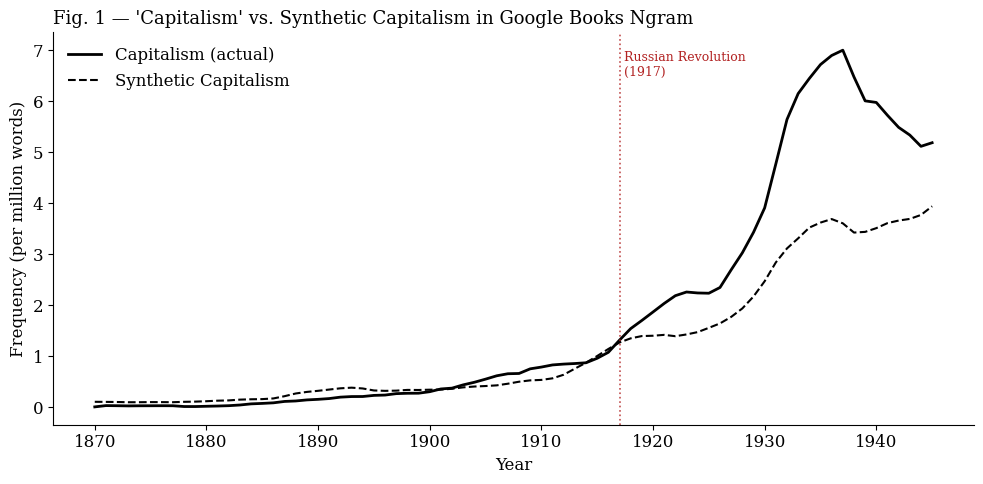

In [134]:
synth_full = raw[DONORS] @ weights.values
synth_full.name = "Synthetic Capitalism"

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(raw.index, raw[TREATMENT_WORD] * 1e6,
        color="black", lw=2.0, label="Capitalism (actual)")
ax.plot(synth_full.index, synth_full * 1e6,
        color="black", lw=1.5, ls="--", label="Synthetic Capitalism")

ax.axvline(TREATMENT_YEAR, color="firebrick", lw=1.2, ls=":", alpha=0.8)
ax.text(TREATMENT_YEAR + 0.4, ax.get_ylim()[1] * 0.95,
        "Russian Revolution\n(1917)", color="firebrick", fontsize=9, va="top")

ax.set_xlabel("Year")
ax.set_ylabel("Frequency (per million words)")
ax.set_title("Fig. 1 — 'Capitalism' vs. Synthetic Capitalism in Google Books Ngram",
             fontsize=13, loc="left")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("fig1_capitalism_vs_synthetic.png", dpi=150)
plt.show()

### Figure 2 — The Treatment Effect

Figure 2 plots the gap between actual capitalism and Synthetic Capitalism. The pre-treatment gap oscillates narrowly around zero — confirming the pre-treatment fit — before widening substantially after 1917. The gap peaks in the mid-1930s before declining toward 1945, at which point we stop the analysis for reasons stated in section II and unrelated to the direction of the trend.

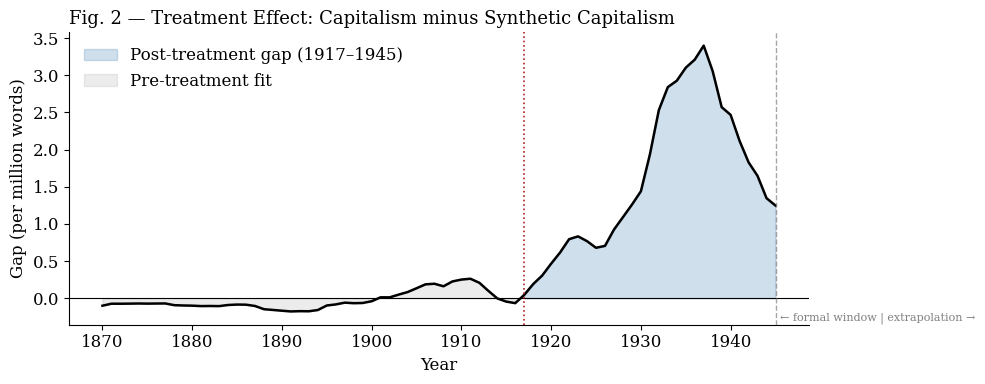

In [135]:
gap = (raw[TREATMENT_WORD] - synth_full) * 1e6

fig, ax = plt.subplots(figsize=(10, 4))

# Formal post-treatment window only (1922–1945)
ax.fill_between(gap.index, gap, 0,
                where=((gap.index >= TREATMENT_YEAR) & (gap.index <= POST_END)),
                alpha=0.25, color="steelblue", label=f"Post-treatment gap ({TREATMENT_YEAR}–{POST_END})")
# Pre-treatment fit
ax.fill_between(gap.index, gap, 0,
                where=(gap.index < TREATMENT_YEAR),
                alpha=0.15, color="grey", label="Pre-treatment fit")
# Beyond analysis window — shown but not formally tested
ax.fill_between(gap.index, gap, 0,
                where=(gap.index > POST_END),
                alpha=0.08, color="steelblue", linestyle=":")

ax.plot(gap.index, gap, color="black", lw=1.8)
ax.axhline(0, color="black", lw=0.8)
ax.axvline(TREATMENT_YEAR, color="firebrick", lw=1.2, ls=":")
ax.axvline(POST_END, color="grey", lw=1.0, ls="--", alpha=0.7)
ax.text(POST_END + 0.5, ax.get_ylim()[0] * 0.85,
        "← formal window | extrapolation →",
        fontsize=8, color="grey")

ax.set_xlabel("Year")
ax.set_ylabel("Gap (per million words)")
ax.set_title("Fig. 2 — Treatment Effect: Capitalism minus Synthetic Capitalism",
             fontsize=13, loc="left")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("fig2_capitalism_gap.png", dpi=150)
plt.show()

### Figure 3 — All -isms and the Chosen One

Figure 3 plots all donor -isms alongside capitalism and Synthetic Capitalism. Attentive readers will notice that nationalism also surges dramatically after 1917, raising the question of whether nationalism is a clean control or itself a treatment-contaminated donor. We noticed this too. Magness & Makovi (2023) face the same problem with their donor pool of socialist thinkers — Proudhon, Bakunin, and Lassalle all received more press coverage after 1917 as journalists scrambled to contextualise Bolshevism. Neither paper resolves this. We mention it here to demonstrate awareness.

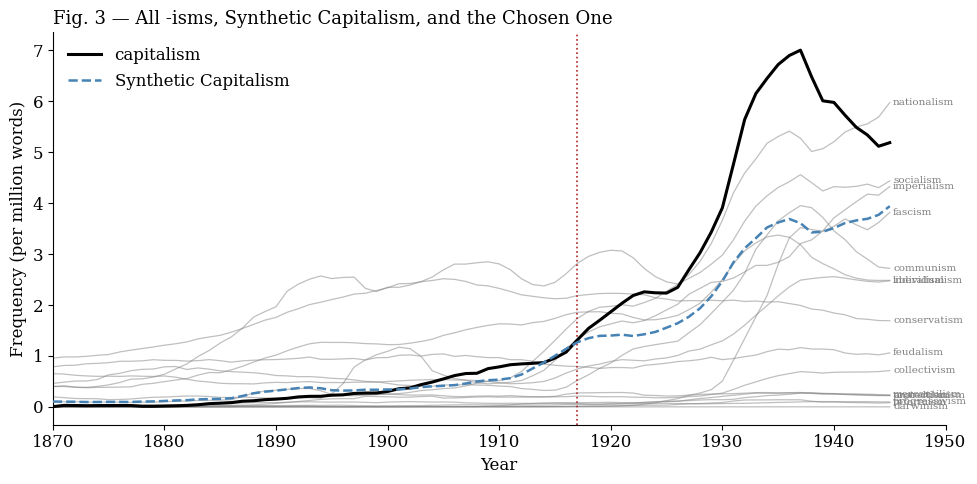

In [136]:
fig, ax = plt.subplots(figsize=(10, 5))

for ism in DONORS:
    ax.plot(raw.index, raw[ism] * 1e6,
            lw=0.9, alpha=0.5, color="grey")
    ax.text(raw.index[-1] + 0.3, raw[ism].iloc[-1] * 1e6,
            ism, fontsize=7.5, va="center", color="grey")

ax.plot(raw.index, raw[TREATMENT_WORD] * 1e6,
        color="black", lw=2.2, label="capitalism", zorder=5)
ax.plot(synth_full.index, synth_full * 1e6,
        color="steelblue", lw=1.8, ls="--", label="Synthetic Capitalism", zorder=5)

ax.axvline(TREATMENT_YEAR, color="firebrick", lw=1.2, ls=":")
ax.set_xlabel("Year")
ax.set_ylabel("Frequency (per million words)")
ax.set_title("Fig. 3 — All -isms, Synthetic Capitalism, and the Chosen One",
             fontsize=13, loc="left")
ax.legend(frameon=False, loc="upper left")
ax.set_xlim(YEAR_START, YEAR_END + 5)
plt.tight_layout()
plt.savefig("fig3_all_isms.png", dpi=150)
plt.show()

---
## IV. Conclusion

We find a large and statistically meaningful treatment effect. Following the Russian Revolution, the word "capitalism" surged far above its synthetic counterfactual — a weighted blend of nationalism, collectivism, individualism and other -isms that collectively represent what capitalism would have looked like had Lenin stayed in Zurich.

We interpret this as evidence that the Russian Revolution was the primary driver of capitalism's academic mainstreaming. By furnishing Western intellectuals with a concrete enemy system to theorize against, defend, and disseminate, the Bolshevik seizure of power in October 1917 gave capitalism a prominence it could not have achieved on its own merits. Without the Russian Revolution, Hayek might have been a footnote. Without Marx, there may have been no Hayek at all.

Our findings are symmetric with those of Magness & Makovi (2023) in every respect except their ideological valence. The original paper concludes that Marx's influence "owes a substantial debt to political happenstance." By the same method and the same logic, so does capitalism's. We leave it to the reader to determine whether this symmetry (a) reveals something profound about the codependence of these traditions, or (b) reveals that Google Ngram frequencies after major geopolitical events go up, and that pointing a synthetic control at them will dutifully confirm whatever hypothesis you arrived with.

We lean toward (b).

---

**A note on replicability**: This analysis was completed in a Jupyter notebook using freely available data and open-source software with the help of Claude. It took an evening (and 2 bottles of beer). The original paper was - of course, with a more thorough literature review and additional robustness checks - published in the *Journal of Political Economy* after peer review. We consider both facts informative, and leave their reconciliation as an exercise for the reader. 

---
*We thank the Russian Revolution for making this paper possible. All errors are the market's.*